# EDA 

In [27]:
#  Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [3]:
df = pd.read_csv(r"../dataset/covtype.csv")

df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3


In [4]:
# Null Values

print(df.isnull().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [5]:
# Stats 

print(df.describe())

           Elevation         Aspect          Slope  \
count  581012.000000  581012.000000  581012.000000   
mean     2959.365301     155.656807      14.103704   
std       279.984734     111.913721       7.488242   
min      1859.000000       0.000000       0.000000   
25%      2809.000000      58.000000       9.000000   
50%      2996.000000     127.000000      13.000000   
75%      3163.000000     260.000000      18.000000   
max      3858.000000     360.000000      66.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                     581012.000000                   581012.000000   
mean                         269.428217                       46.418855   
std                          212.549356                       58.295232   
min                            0.000000                     -173.000000   
25%                          108.000000                        7.000000   
50%                          218.000000                       3

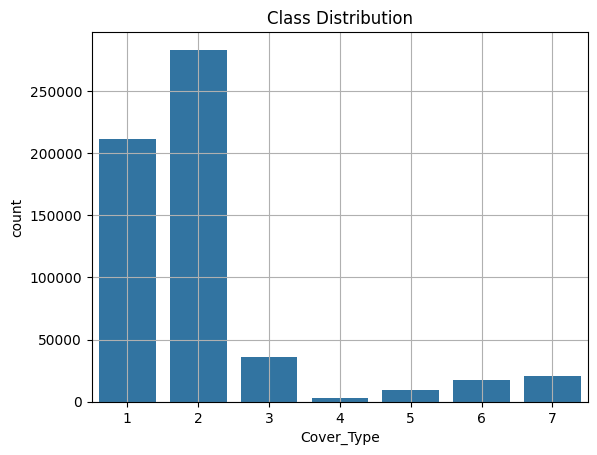

In [6]:
# Class Imbalance Check

sns.countplot(
    x = "Cover_Type" ,
    data = df
)

plt.title("Class Distribution")
plt.grid()
plt.show()

# Highly Imbalanced Dataset 

# class 4 is having very low count while class 2 is soo high in count 

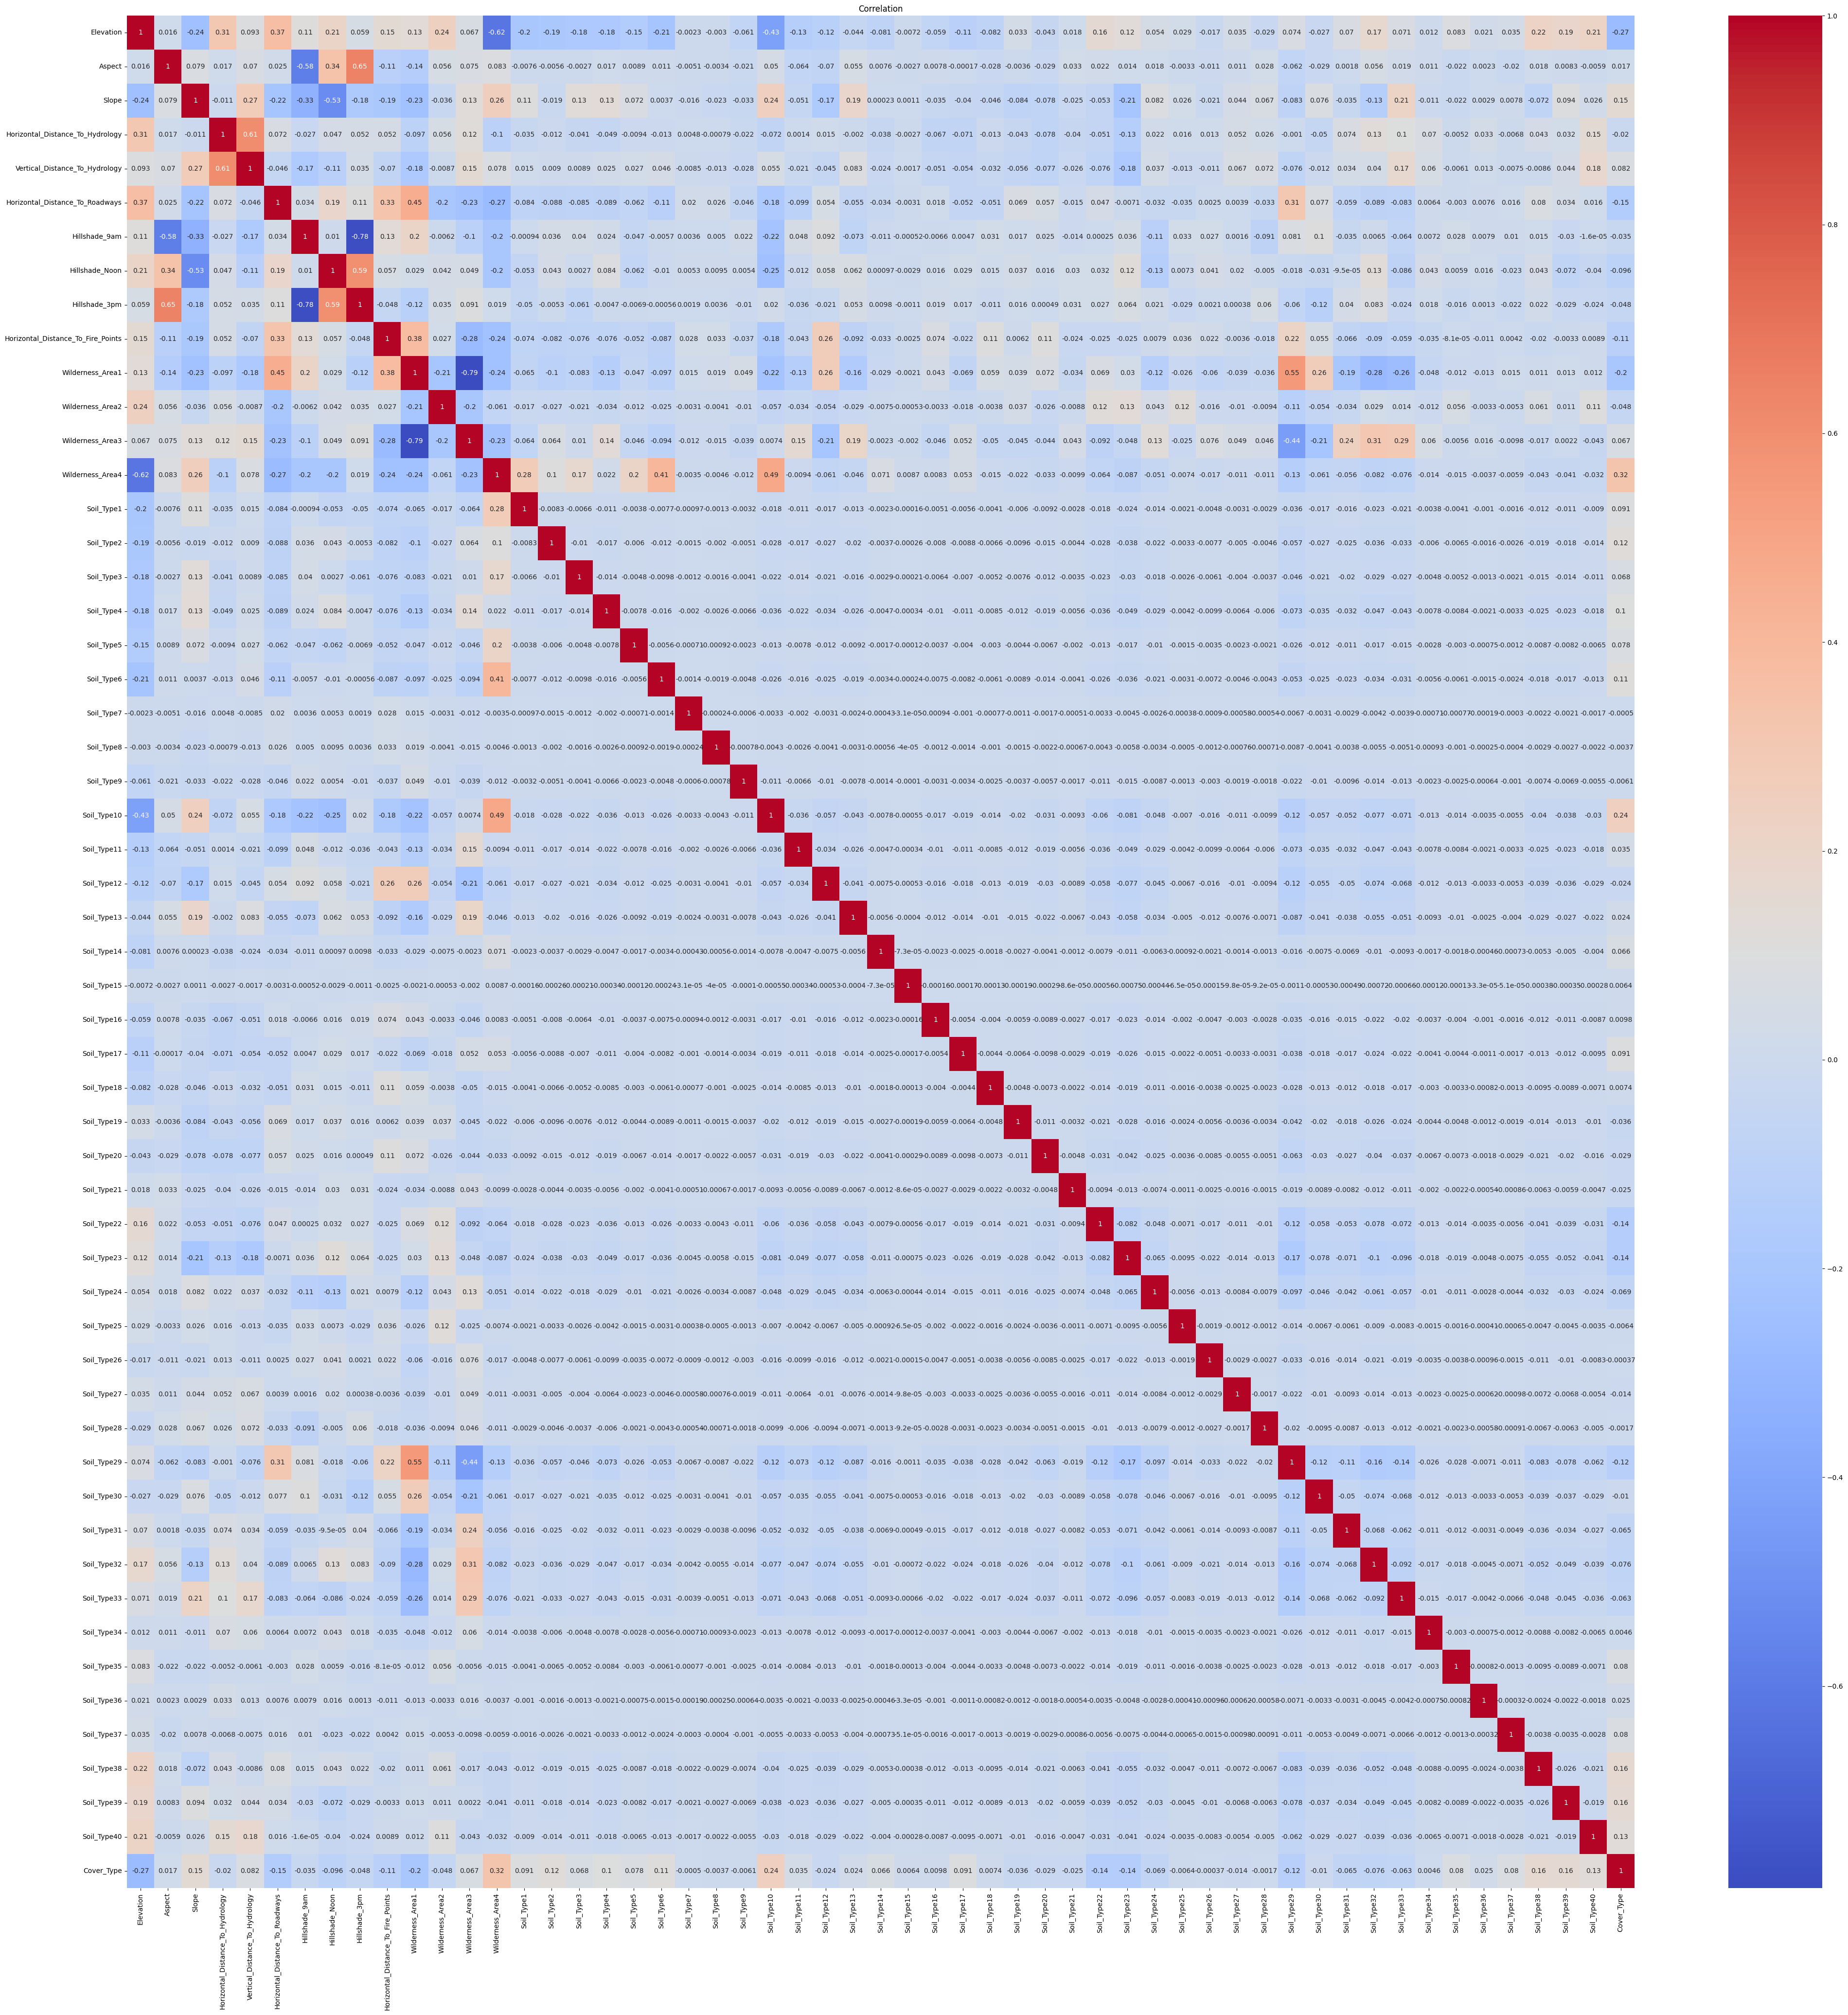

In [7]:
# Heat Map

plt.figure(figsize=(50 , 50))
sns.heatmap(
    df.corr(numeric_only = True) ,
    annot = True ,
    cmap = "coolwarm"
)

plt.title("Correlation")
plt.show()

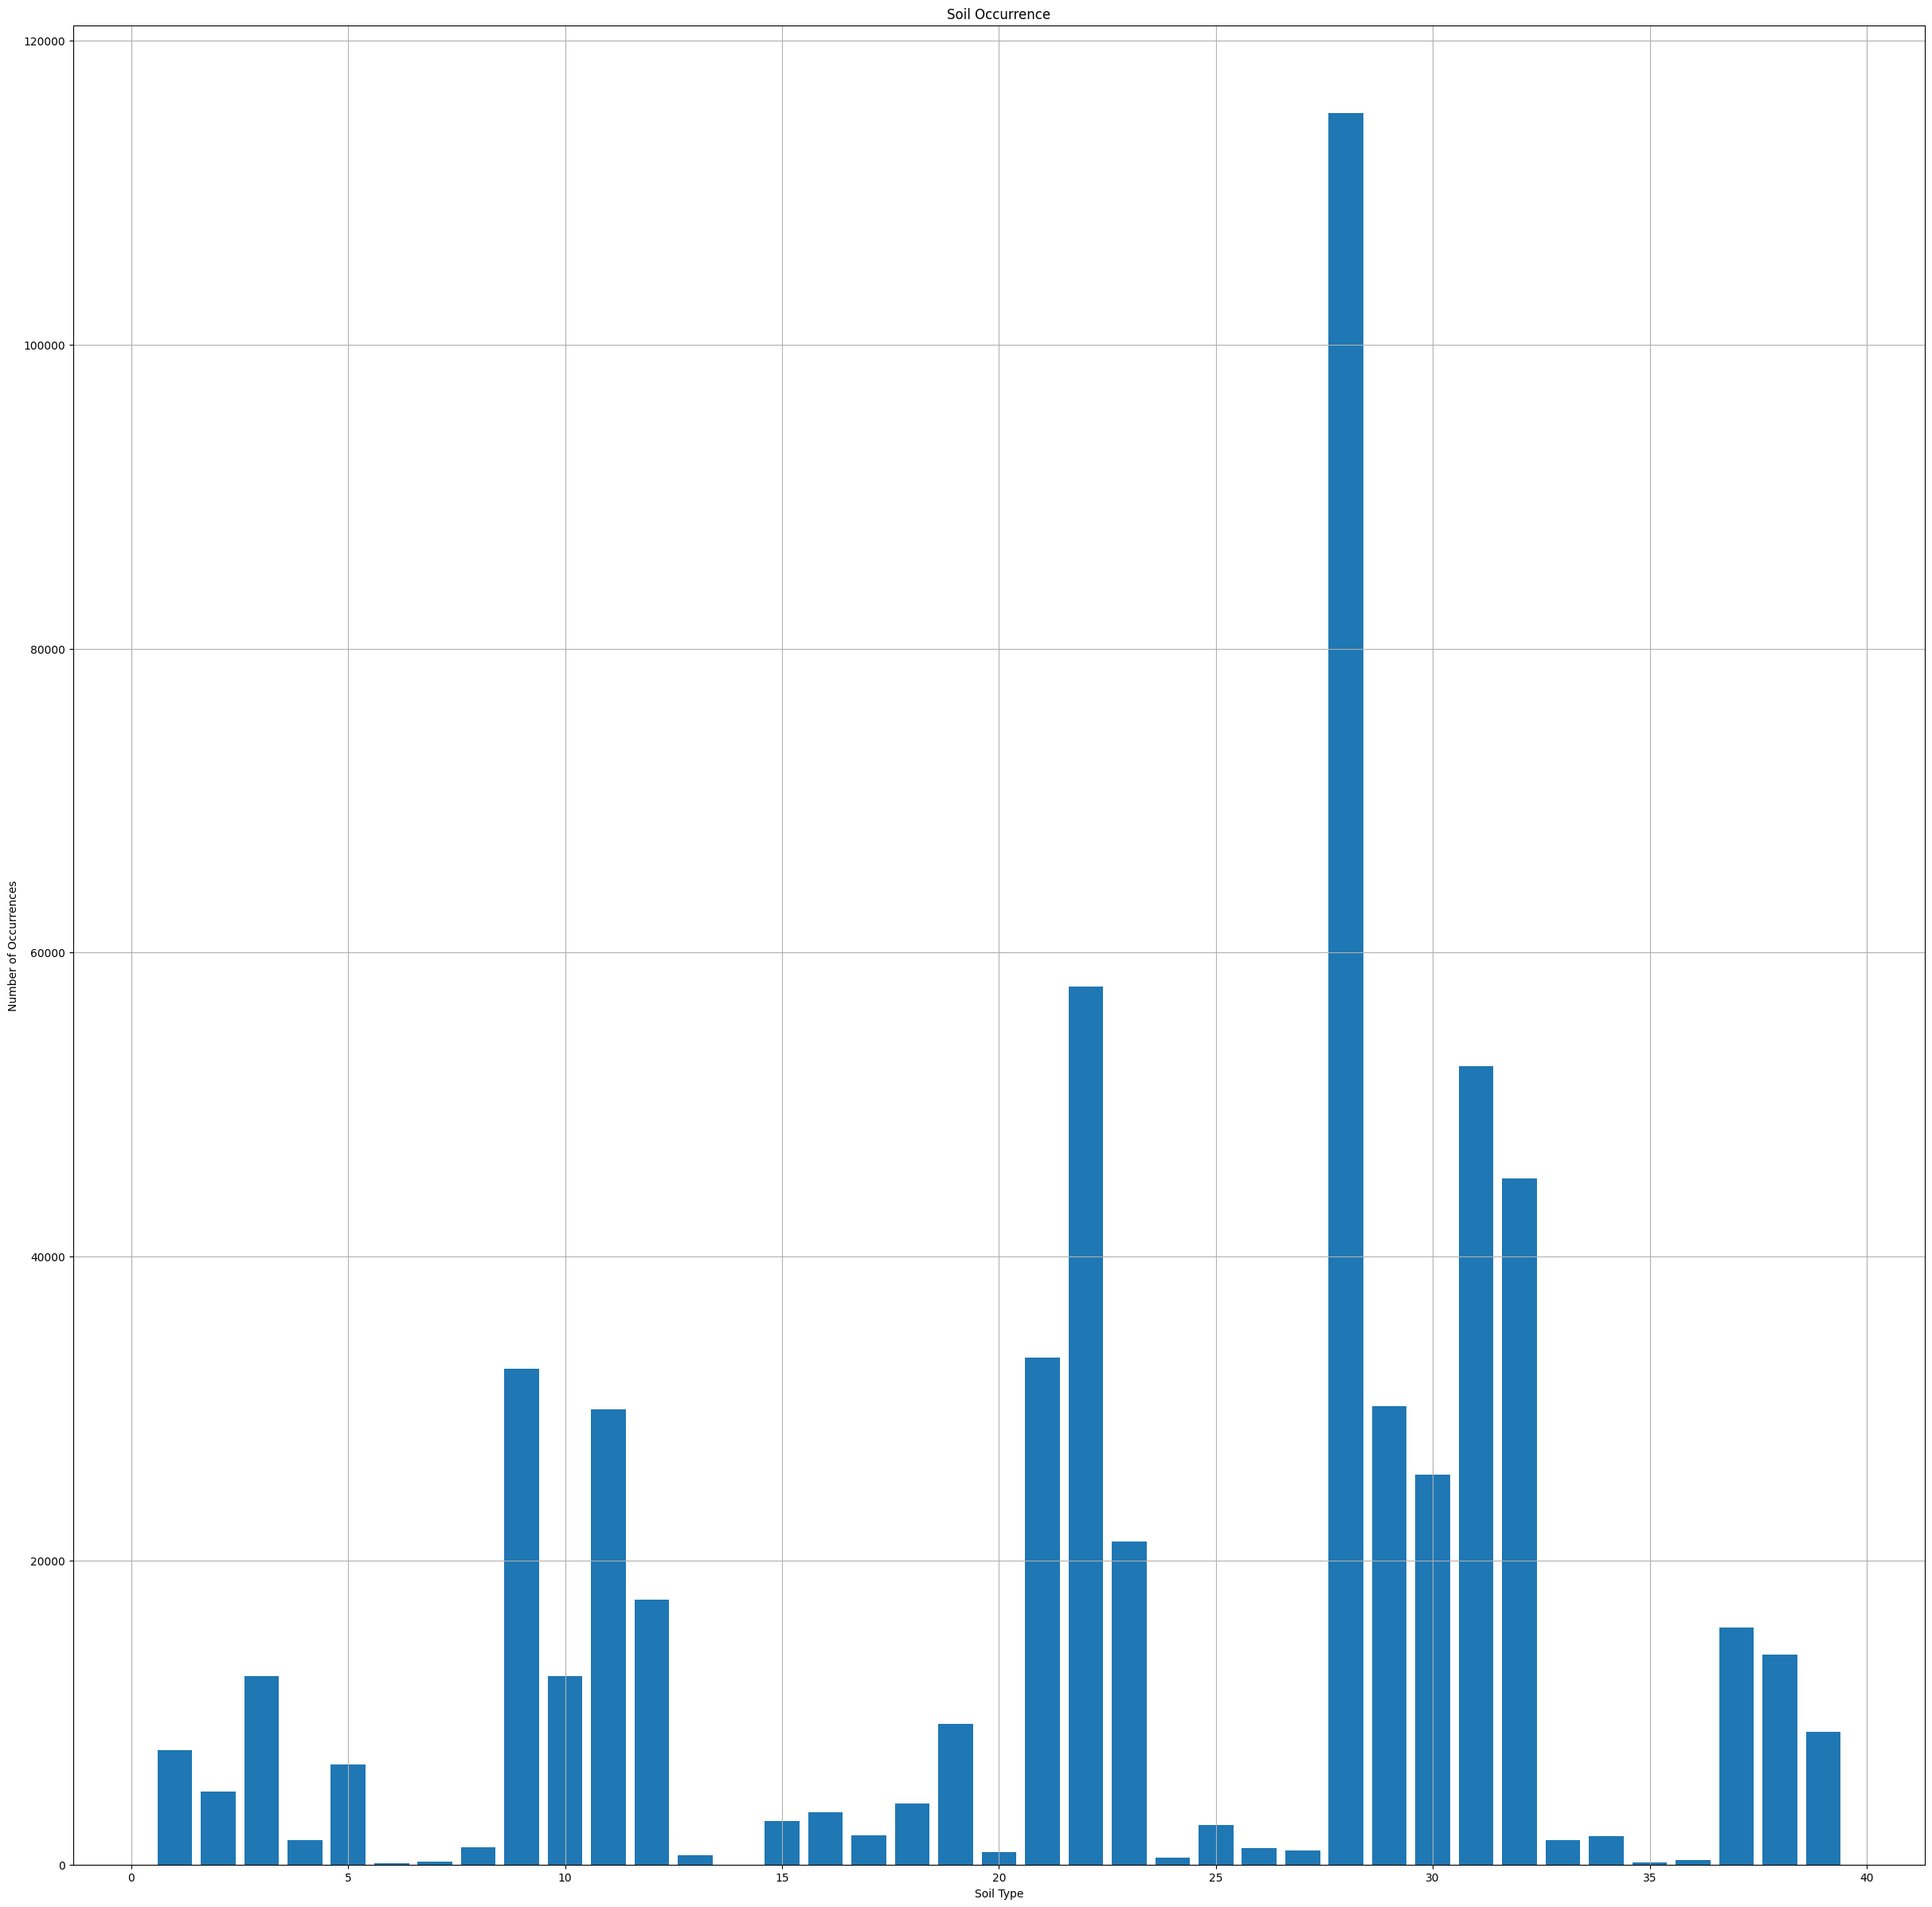

In [20]:
# Soil Type Occurance

soil_type = df.iloc[: ,14 : 54]

soil_type = soil_type.agg(sum)

soil_type = soil_type.reset_index()

soil_type = soil_type.drop(["index"] , axis=1)

soil_type = pd.Series(soil_type[0])
soil_type = pd.Series(soil_type , index = soil_type.index + 1)


plt.figure(figsize=(30 , 30))

plt.bar(
    x=soil_type.index,
    height=soil_type.values
)

plt.xlabel("Soil Type")
plt.ylabel("Number of Occurrences")
plt.title("Soil Occurrence")
plt.grid()
plt.show()

# Soil  "28" is most often found while few of them are very less

In [35]:
# Feature Importance

X = df.drop(["Cover_Type"] , axis = 1)
yy = df["Cover_Type"]

weights = compute_sample_weight(
    class_weight = "balanced" ,
    y = yy
)

EDA_model = RandomForestClassifier()
EDA_model.fit(X , y , sample_weight = weights)

imp = pd.Series(EDA_model.feature_importances_ , index = X.columns).sort_values(ascending=False)

print(imp)

Elevation                             0.239710
Horizontal_Distance_To_Roadways       0.110704
Horizontal_Distance_To_Fire_Points    0.088167
Horizontal_Distance_To_Hydrology      0.059176
Vertical_Distance_To_Hydrology        0.052686
Wilderness_Area4                      0.044719
Aspect                                0.042987
Hillshade_9am                         0.042637
Hillshade_3pm                         0.037363
Hillshade_Noon                        0.035854
Slope                                 0.027436
Soil_Type10                           0.023624
Wilderness_Area1                      0.018980
Soil_Type38                           0.018134
Wilderness_Area3                      0.017744
Soil_Type3                            0.017229
Soil_Type39                           0.016638
Soil_Type4                            0.013561
Soil_Type40                           0.009209
Soil_Type2                            0.008049
Soil_Type30                           0.007191
Soil_Type13  